# Load packages

Read in all necessary packages:

In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scanpy as sc
import numpy as np
#import decoupler as dc
from scipy.stats import ranksums
import numpy as np
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats
from statsmodels.stats.multitest import multipletests

In [2]:
sc.set_figure_params(dpi = 80)
sns.set_style("white")
sns.set_context("talk")
sns.set_style("ticks")

# Load the dataset

## load adata file and define groups for differential expression

In [3]:
adata = sc.read_h5ad('input/20230619_allGastruloids_UMAP_celltypes_incChroms_norm.h5ad')
adata

AnnData object with n_obs × n_vars = 38117 × 27384
    obs: 'batch2', 'batch', 'day', 'replicates', 'mark', 'day_rep', 'dataset', 'cellnames', 'bc', 'cellname', 'percent_mito', 'n_counts', 'n_counts_proteincoding', 'n_counts_stressgenes', 'n_genes', 'S_score', 'G2M_score', 'phase', 'histone_score', 'mark_binary', 'enrichment', 'coverage', 'QC', 'umap_density_mark', 'predicted_id_E75', 'predicted_id_E85', 'prediction_confidence_E75', 'prediction_confidence_E85', 'predicted_final', 'leiden', 'celltype', 'old_leiden_general', 'old_celltype', 'old_leiden_merge', 'umap_1D', 'umap_1D_rescale', 'celltype_general', 'lineage', 'lin_day', 'hour', 'PT1', 'PT2', 'PT1_avg', 'K4_total', 'K27_total', 'K4_total_log', 'K27_total_log', 'RNA_total_log'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene', 'gene_biotype', 'gene_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'QC_colors', 'batch_colors', 'celltype_colors', 'celltype_

In [4]:
sc.settings.verbosity = 2

## load the tables with differentially expressed genes

In [5]:
PvsDIFF = pd.read_csv('input/20250310_diff_genes_PvsDIFF.csv')
ESCvsP = pd.read_csv('input/20250310_diff_genes_ESCvsP.csv')
PvsECT = pd.read_csv('input/20250310_diff_genes_PvsECT.csv')
PvsEND = pd.read_csv('input/20250310_diff_genes_PvsEND.csv')
PvsMES = pd.read_csv('input/20250310_diff_genes_PvsMES.csv')

In [6]:
def up_down_genes(results_df):
    up = results_df[(results_df['padj'] < 0.05) & (results_df['log2FoldChange'] > 2)].sort_values(by = 'log2FoldChange',ascending=True)
    down = results_df[(results_df['padj'] < 0.05) & (results_df['log2FoldChange'] < -2)].sort_values(by = 'log2FoldChange',ascending=True)
    return up,down


In [7]:
PvsDIFF_up, PvsDIFF_down = up_down_genes(PvsDIFF)
ESCvsP_up, ESCvsP_down = up_down_genes(ESCvsP)
PvsECT_up, PvsECT_down = up_down_genes(PvsECT)
PvsEND_up, PvsEND_down = up_down_genes(PvsEND)
PvsMES_up, PvsMES_down = up_down_genes(PvsMES)

# Take only unique differentially expressed genes

For the lineages, we take the "up" fraction - these are upregulated in lin vs pluripotent. \
For pluripotency, we take the "down" fraction in p vs diff - these are downregulated in the lineages compared to pluripotency, i.e. they are up in pluripotency. \
For ESCs, we take the "down" fraction in ESC vs p - these are donwregulated in ESCs compared to P. The "up" fraction is differentially expresssed in pluripotent compared to ESCs.

In [8]:
ecto = PvsECT_up[~PvsECT_up['Gene'].isin(list(PvsEND_up['Gene']) + list(PvsMES_up['Gene']))]
meso = PvsMES_up[~PvsMES_up['Gene'].isin(list(PvsEND_up['Gene']) + list(PvsECT_up['Gene']))]
endo = PvsEND_up[~PvsEND_up['Gene'].isin(list(PvsECT_up['Gene']) + list(PvsMES_up['Gene']))]
pluri = PvsDIFF_down

ecto.to_csv('dfs/20250416_non_overlapping_diff_expressed_ect.csv')
meso.to_csv('dfs/20250416_non_overlapping_diff_expressed_mes.csv')
endo.to_csv('dfs/20250416_non_overlapping_diff_expressed_end.csv')

In [9]:
metadata = pd.read_csv('input/20250304_metadata.tsv', index_col = 0, header = 0, low_memory= False, sep = '\t')

In [10]:
metadata.head(2)

,step,PT,UMAP1,UMAP2,lin,RT,lin2,RT_m,step_id
1,1,0.372537,11.126464,4.599585,ect1,mESCs,Pluripotent mESCs,0.0,1:ect1
2,2,0.463342,11.385221,4.509028,ect1,mESCs,Pluripotent mESCs,0.0,2:ect1


In [11]:
count_table = pd.read_csv('input/20250304_count_data_all_thresh_min.tsv', sep = '\t', index_col = 0)

In [12]:
count_table.index = count_table['gene']
count_table.head(2)

,gene,step,layer,counts,lin,sm_short,counts_log2,sm_short_log2,sm_short_state_fix,sm_short_state_dyn
gene,,,,,,,,,,
Xkr4,Xkr4,1,RNA,0.25,ect1,0.284,-1.943416,-1.766112,1.0,0.0
Rp1,Rp1,1,RNA,0.23,ect1,0.278,-2.058894,-1.795859,0.0,0.0


In [13]:
d_rna = {}
d_k4 = {}
d_k27 = {}
df_rna = count_table[count_table['layer'] == 'RNA']
df_k4 = count_table[count_table['layer'] == 'K4']
df_k27 = count_table[count_table['layer'] == 'K27']

df_rna = df_rna.drop('gene',axis=1)
df_k4 = df_k4.drop('gene',axis=1)
df_k27 = df_k27.drop('gene',axis=1)

In [14]:
ct_normalised = pd.concat([df_rna,df_k4,df_k27])

In [15]:
ct_normalised.head(2)

,step,layer,counts,lin,sm_short,counts_log2,sm_short_log2,sm_short_state_fix,sm_short_state_dyn
gene,,,,,,,,,
Xkr4,1,RNA,0.25,ect1,0.284,-1.943416,-1.766112,1.0,0.0
Rp1,1,RNA,0.23,ect1,0.278,-2.058894,-1.795859,0.0,0.0


In [16]:

ct_normalised['step_id'] = ct_normalised['step'].astype(str) + str(':') + ct_normalised['lin']
metadata['step_id'] = metadata['step'].astype(str) + str(':') + metadata['lin']
steps_to_RT = metadata[['step_id','RT']].set_index('step_id').to_dict()['RT']
ct_normalised['RT'] = ct_normalised['step_id'].map(steps_to_RT)
ct_normalised['RT'] = ct_normalised['RT'].astype('category')
ct_normalised['RT'] = ct_normalised['RT'].cat.reorder_categories(['mESCs','Gastd3', 'Gastd4', 'Gastd5', 'Gastd6', 'Gastd7'])
ct_normalised['lin_layer'] = ct_normalised['lin'].astype(str) + str('_') + ct_normalised['layer'].astype(str)


In [17]:
ct_normalised.head(2)

,step,layer,counts,lin,sm_short,counts_log2,sm_short_log2,sm_short_state_fix,sm_short_state_dyn,step_id,RT,lin_layer
gene,,,,,,,,,,,,
Xkr4,1,RNA,0.25,ect1,0.284,-1.943416,-1.766112,1.0,0.0,1:ect1,mESCs,ect1_RNA
Rp1,1,RNA,0.23,ect1,0.278,-2.058894,-1.795859,0.0,0.0,1:ect1,mESCs,ect1_RNA


0
547


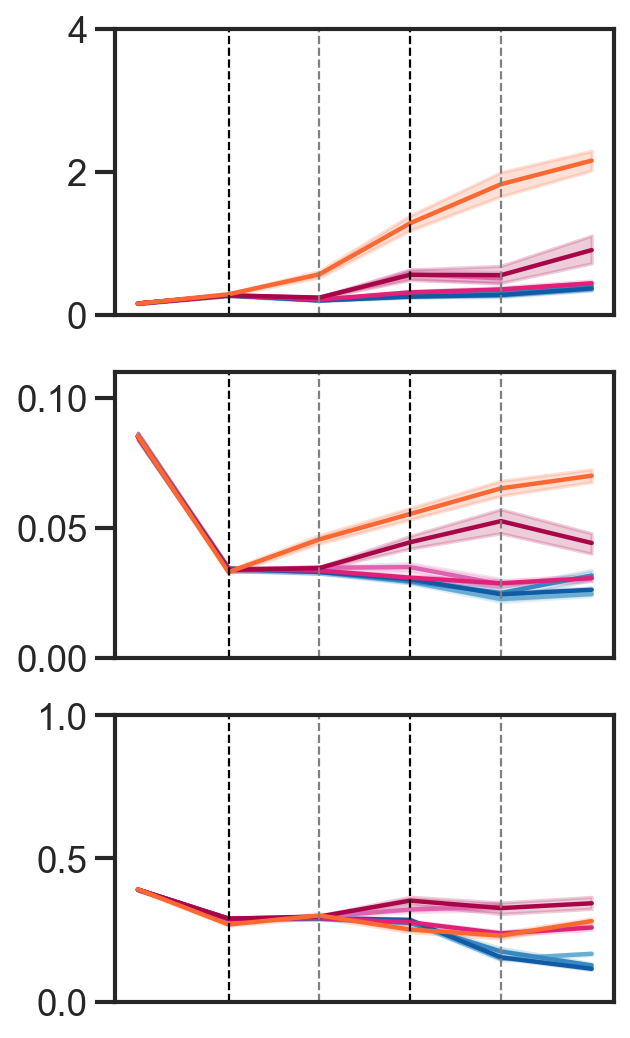

1
365


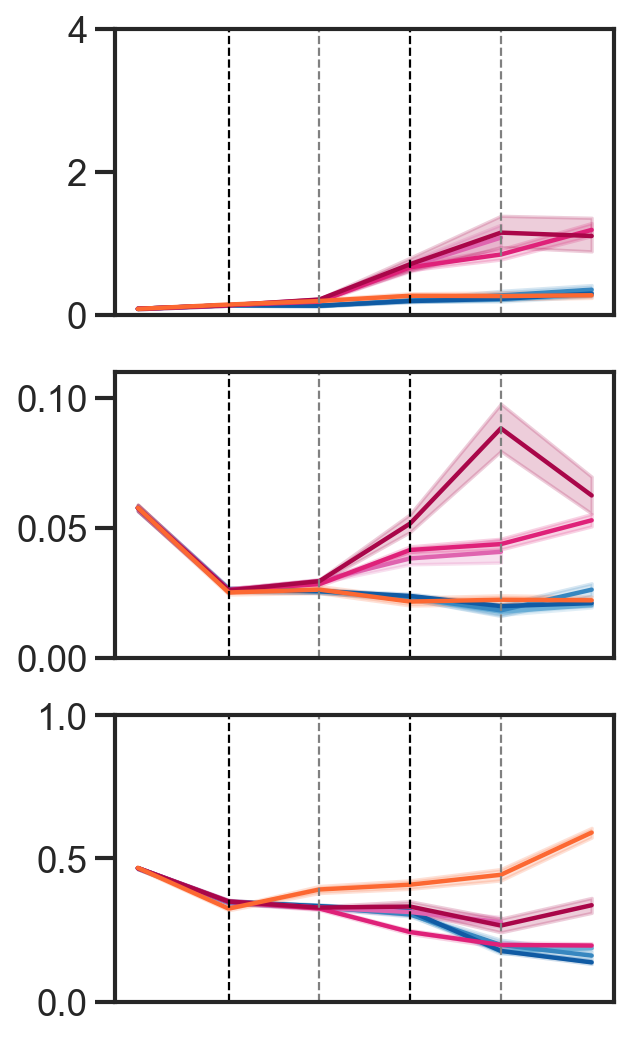

2
290


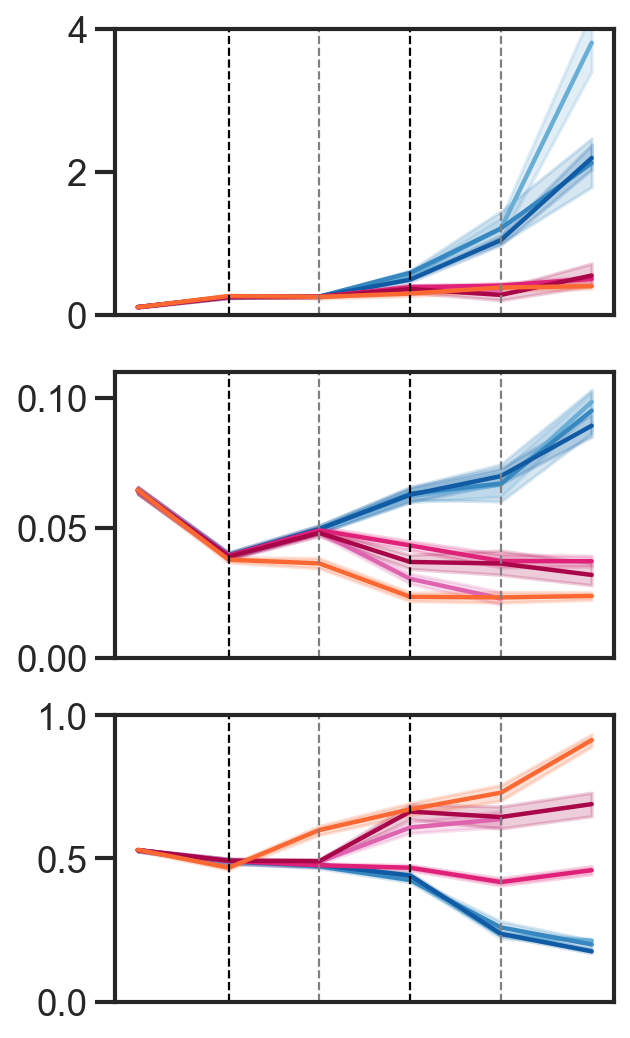

In [18]:
xval = 'RT'
yval = 'counts'
hue = 'lin'
hue_order = ['ect1','ect2','ect3',
            'mes1','mes2','mes3',
            'endo1',]
palette = ['#6AAED6', '#3787C0', '#105BA4', '#DF64AF', '#DF2179', '#A90649', '#FC6832',]

mod = ['RNA', 'K4','K27']
plots = [endo,meso,ecto]
order = ['endo','meso','ecto']

for num, item in enumerate(plots):
    print(num)
    to_plot = ct_normalised.loc[ct_normalised.index.isin(item['Gene'])]

    #to_plot = ct_normalised.loc[item[item['Gene'].isin(ct_normalised.index)]['Gene']]
    print(len(to_plot.index.unique()))
    fig,ax = plt.subplots(3,1, figsize = (4,8))
    for x in range(3):
        sns.lineplot(data = to_plot[to_plot['layer'] == mod[x]], linewidth = 2,
                     ax=ax[x],
                     x = xval, y = yval,hue = hue,hue_order = hue_order, palette = palette, estimator='mean')
    
        ax[x].set_title('')
        if x==0:
            ax[x].set_ylim([0,4])
        if x==1:
            ax[x].set_ylim([0,0.11])
        if x==2:
            ax[x].set_ylim([0,1])

    for axes in ax:
        axes.set_xlabel('')
        axes.set_ylabel('')
        #axes.set_ylim([0,1])
        axes.set_xticks([])
        axes.legend([],frameon=False) 
        axes.axvline('Gastd3',linestyle = 'dashed',c = 'black',linewidth = 1)
        axes.axvline('Gastd5',linestyle = 'dashed',c = 'black',linewidth = 1)
        axes.axvline('Gastd4',linestyle = 'dashed',c = 'grey',linewidth = 1)
        axes.axvline('Gastd6',linestyle = 'dashed',c = 'grey',linewidth = 1)
    plt.savefig('figures/Fig6f_lineplot_mean_RT_counts_' +str(order[num]) + '.pdf', bbox_inches='tight', format='pdf')
    plt.show()

In [19]:
#Prepare data for differential expression analysis per real time point to identify day of signifcant change per gene set
#to determine p values realtive to the pluripotent cell clusters

adata.obs['plates']=adata.obs['batch'].str.split('-').str[-1]
adata.obs.loc[adata.obs['plates']=='7','plates']='1'
adata.obs.loc[adata.obs['plates']=='8','plates']='2'
adata.obs.loc[adata.obs['plates']=='9','plates']='3'
adata.obs.loc[adata.obs['plates']=='10','plates']='4'
adata.obs.loc[adata.obs['plates']=='11','plates']='5'
adata.obs.loc[adata.obs['plates']=='12','plates']='6'

adata.obs['cluster']=adata.obs['lin_day'].astype(str)

list_to_exclude={'Endoderm mESCs','Pluripotent Gastd3','Pluripotent Gastd4','Pluripotent Gastd5','Pluripotent Gastd6','Pluripotent Gastd7'}
adata.obs.loc[adata.obs['lin_day'].isin(list_to_exclude),'cluster']='ignore'

adata.obs['cluster2']=adata.obs['lin_day'].astype(str)

list_to_exclude={'Endoderm mESCs','Pluripotent Gastd5','Pluripotent Gastd6','Pluripotent Gastd7','Pluripotent mESCs','PGCs','Epiblast'}
list_to_combine={'Pluripotent Gastd3','Pluripotent Gastd4'}

adata.obs.loc[adata.obs['lin_day'].isin(list_to_exclude),'cluster2']='ignore'
adata.obs.loc[adata.obs['lin_day'].isin(list_to_combine),'cluster2']='Pluripotent'
adata.obs.loc[adata.obs['celltype_general'].isin(list_to_exclude),'cluster2']='ignore'




In [20]:
lineages=pd.read_csv("input/20240202_9trajectories.csv", sep = ',', header = 0 ,index_col=0)



#add mESCs to linages and remove reprogramming PGCs 
lineages[lineages.index.isin(adata[adata.obs['celltype']=='mESCs'].obs.index)]='mESCs'
lineages=lineages[~lineages.index.isin(adata[adata.obs['celltype']=='Reprogramming PGCs'].obs.index)]



ect1_ct=lineages['ect1_ct'].dropna().index
ect2_ct=lineages['ect2_ct'].dropna().index
ect3_ct=lineages['ect3_ct'].dropna().index
mes1_ct=lineages['mes1_ct'].dropna().index
mes2_ct=lineages['mes2_ct'].dropna().index
mes3_ct=lineages['mes3_ct'].dropna().index
end1_ct=adata.obs[adata.obs['celltype'].isin(['mESCs','Caudal Epiblast','Primitive Streak','Visceral Endoderm','ExE Endoderm'])].index


In [21]:
#from pydeseq2.dds import DeseqDataSet
#from pydeseq2.ds import DeseqStats

# Define reference cluster


lins={'ect1':ect1_ct,'ect2':ect2_ct,'ect3':ect3_ct,'mes1':mes1_ct,'mes2':mes2_ct,'mes3':mes3_ct,'end1':end1_ct}


fulltable=pd.DataFrame()

for day in ['Gastd4', 'Gastd5', 'Gastd6', 'Gastd7']:
    for linname,lin in lins.items():
        for rep in ['1','2','3','4','5','6']:
            selection=adata[((adata.obs['day']==day)&(adata.obs['plates']==rep)&(adata.obs['cellname'].isin(lin))&(adata.obs['lineage']!="Pluripotent"))].copy()
            selection.var.index = pd.Index(selection.var.index.map(str), dtype="str")
            raw_counts = pd.DataFrame(selection.layers["matrix"].toarray(),columns=selection.var.index.astype(str))
            name=rep + "_" + linname + "_" + day
            fulltable[name]=raw_counts.sum().T.astype(float)
            fulltable=fulltable.copy()

day='Gastd3'
for linname,lin in lins.items():
    for rep in ['1','2','3','4','5','6']:
        selection=adata[((adata.obs['day']==day)&(adata.obs['plates']==rep)&(adata.obs['cellname'].isin(lin))&(adata.obs['lineage']=="Pluripotent"))].copy()
        selection.var.index = pd.Index(selection.var.index.map(str), dtype="str")
        raw_counts = pd.DataFrame(selection.layers["matrix"].toarray(),columns=selection.var.index.astype(str))
        name=rep + "_" + linname + "_" + day
        fulltable[name]=raw_counts.sum().T.astype(float)
        fulltable=fulltable.copy()


for rep in ['1','2','3','4','5','6']:
    selection=adata[((adata.obs['day']=='mESCs')&(adata.obs['plates']==rep))].copy()
    raw_counts = pd.DataFrame(selection.layers["matrix"].toarray(),columns=selection.var.index.astype(str))
    name=rep + "_" + "Pluripotent" + "_" + 'mESCs'
    fulltable[name]=raw_counts.sum().T.astype(float)
    fulltable=fulltable.copy()



In [22]:



metadata=pd.DataFrame({'group':fulltable.columns.unique(), 'rep':[s.split('_', 1)[0] for s in fulltable.columns.unique()], 'cluster':[s.split('_', 1)[1] for s in fulltable.columns.unique()]}).set_index("group")

reference_cluster = "Pluripotent_mESCs"
clusters = metadata["cluster"].unique().tolist()
clusters.remove(reference_cluster)

metadata["cluster"] = pd.Categorical(
    metadata["cluster"],
    categories=[reference_cluster] + [c for c in clusters if c != reference_cluster]
)





In [24]:
results_all = {}

for target_cluster in clusters:
    print(f"\n🧪 Comparing {target_cluster} vs {reference_cluster}")

    # Filter metadata for reference and target cluster
    meta_sub = metadata[metadata["cluster"].isin([reference_cluster, target_cluster])].copy()
    meta_sub["cluster"] = meta_sub["cluster"].cat.remove_unused_categories()
    # Ensure two levels and ≥2 replicates per level
    if meta_sub["cluster"].nunique() < 2:
        continue
    vc = meta_sub["cluster"].value_counts()
    if (vc < 2).any():
        continue

    samples = meta_sub.index.tolist()

    # Get counts for those samples
    counts_sub = fulltable[samples].T  # samples x genes
    
    keep = (counts_sub.sum(axis=0) >= 10)  # exclude genes with too low reads
    counts_sub = counts_sub.loc[:, keep]


    # Build DESeq2 dataset
    dds = DeseqDataSet(
        counts=counts_sub,
        metadata=meta_sub,
        design="~ 0 + C(cluster)"
    )
    dds.deseq2()

    stat_res = DeseqStats(dds, contrast=["cluster", target_cluster, reference_cluster])
    stat_res.summary()
    res_df = stat_res.results_df.copy()
    res_df["comparison"] = f"{target_cluster}_vs_{reference_cluster}"

    results_all[target_cluster] = res_df


🧪 Comparing ect1_Gastd4 vs Pluripotent_mESCs


Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 1.45 seconds.

Fitting dispersion trend curve...
... done in 0.34 seconds.

Fitting MAP dispersions...
... done in 1.32 seconds.

Fitting LFCs...
... done in 1.27 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.87 seconds.



Log2 fold change & Wald test p-value: cluster ect1_Gastd4 vs Pluripotent_mESCs
            baseMean  log2FoldChange     lfcSE       stat        pvalue  \
Gene                                                                      
Xkr4      390.605933        3.508460  0.214213  16.378373  2.729488e-60   
Gm37381     4.408646       -1.787986  0.778423  -2.296934  2.162252e-02   
Rp1        33.883990       -2.797260  0.404172  -6.920958  4.486002e-12   
Sox17       2.503567        0.690954  0.776434   0.889908  3.735155e-01   
Mrpl15    385.915177       -1.229974  0.086740 -14.180028  1.217977e-45   
...              ...             ...       ...        ...           ...   
Eif2s3y    19.359954       -1.051128  0.333578  -3.151069  1.626742e-03   
Gm28919     0.956253       -0.726305  1.291230  -0.562491  5.737815e-01   
Gm28510     0.497844       -0.865164  1.538242  -0.562437  5.738185e-01   
Gm20931     1.852606       -2.124100  1.196239  -1.775649  7.579076e-02   
Gm47283  2426.016988 

...

Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 1.18 seconds.

Fitting dispersion trend curve...
... done in 0.35 seconds.

Fitting MAP dispersions...
... done in 1.29 seconds.

Fitting LFCs...
... done in 1.10 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: cluster end1_Gastd3 vs Pluripotent_mESCs
            baseMean  log2FoldChange     lfcSE       stat         pvalue  \
Gene                                                                       
Xkr4     4198.493934        5.401978  0.174407  30.973326  1.232993e-210   
Gm37381    14.097602       -1.542125  0.361568  -4.265107   1.998061e-05   
Rp1       118.142090       -1.817073  0.217425  -8.357252   6.419633e-17   
Sox17      10.271629        1.404880  0.392333   3.580836   3.424970e-04   
Mrpl15   1254.995720       -1.025782  0.046480 -22.069393  6.222157e-108   
...              ...             ...       ...        ...            ...   
Eif2s3y    86.745566        0.145708  0.145889   0.998756   3.179128e-01   
Gm28919     2.707101       -1.440751  0.760225  -1.895163   5.807075e-02   
Gm28510     1.955156       -1.935737  0.897703  -2.156322   3.105855e-02   
Gm20931     7.242899       -1.262901  0.450224  -2.805050   5.030877e-03   
Gm47283  

... done in 0.81 seconds.



results_all = {}

for target_cluster in clusters:
    print(f"\n🧪 Comparing {target_cluster} vs {reference_cluster}")

    # Filter metadata for reference and target cluster
    meta_sub = metadata[metadata["cluster"].isin([reference_cluster, target_cluster])]
    samples = meta_sub.index.tolist()

    # Get counts for those samples
    counts_sub = fulltable[samples].T  # samples x genes

    # Build DESeq2 dataset
    dds = DeseqDataSet(
        counts=counts_sub,
        metadata=meta_sub,
        design_factors="cluster",
        ref_level=['cluster', reference_cluster]
    )
    dds.deseq2()

    stat_res = DeseqStats(dds)
    stat_res.summary()
    res_df = stat_res.results_df.copy()
    res_df["comparison"] = f"{target_cluster}_vs_{reference_cluster}"

    results_all[target_cluster] = res_df

In [25]:
results=pd.DataFrame(columns=['Gene','pvalue','log2FoldChange','comparison','lin','day'])

keylist=clusters

for item in keylist:

    tmp=results_all[item][['pvalue','log2FoldChange','comparison']].reset_index()
    tmp[['lin','day']]=tmp['comparison'].str.split(r'[ _]', expand=True)[[0,1]]
    results=pd.concat([results,tmp], ignore_index=True)

results=results.dropna()
rejected, pvals_corrected, _, _=multipletests(results['pvalue'], alpha=0.05, method='bonferroni')
results['padj']=pvals_corrected

results['-log10_p']=-np.log10(results['padj'].replace(0, np.nan))
deseq_by_day=results
deseq_by_day['layer']='RNA'

deseq_by_day['time']='7'
deseq_by_day.loc[deseq_by_day['day']=='Gastd3','time']=1
deseq_by_day.loc[deseq_by_day['day']=='Gastd4','time']=2
deseq_by_day.loc[deseq_by_day['day']=='Gastd5','time']=3
deseq_by_day.loc[deseq_by_day['day']=='Gastd6','time']=4
deseq_by_day.loc[deseq_by_day['day']=='Gastd7','time']=5


day0=deseq_by_day.loc[deseq_by_day['day']=='Gastd7'].copy()
day0['time']=0
day0['-log10_p']=0
day0['padj']=1


deseq_by_day=pd.concat([deseq_by_day, day0], ignore_index=True)

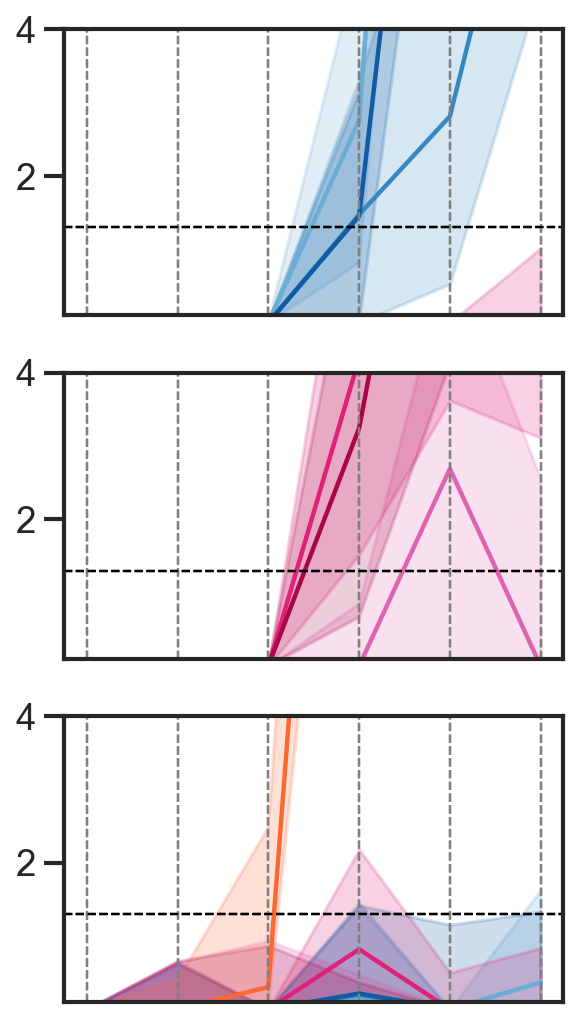

In [26]:
xval = 'time'
yval = '-log10_p'
hue = 'lin'

hue_order = ['ect1','ect2','ect3',
            'mes1','mes2','mes3',
            'end1',]
palette = ['#6AAED6', '#3787C0', '#105BA4', '#DF64AF', '#DF2179', '#A90649', '#FC6832',]


plots = [ecto,meso,endo]
order = ['ecto','meso','endo']
x=0

fig,ax = plt.subplots(3,1, figsize = (4,8))
for num, item in enumerate(plots):
    to_plot = deseq_by_day.loc[deseq_by_day['Gene'].isin(item['Gene'])]
    

    sns.lineplot(data = to_plot, linewidth = 2,
                 ax=ax[x],
                 x = xval, y = yval,hue = hue,hue_order = hue_order, palette = palette,estimator='median')

    ax[x].set_title('')
    ax[x].set_ylim([0.1,4])
    x=x+1

    for axes in ax:
        axes.set_xlabel('')
        axes.set_ylabel('')
        axes.set_xticks([])
        axes.legend([],frameon=False) 
        
        axes.axvline(0,linestyle = 'dashed',c = 'grey',linewidth = 1)
        axes.axvline(1,linestyle = 'dashed',c = 'grey',linewidth = 1)
        axes.axvline(2,linestyle = 'dashed',c = 'grey',linewidth = 1)
        axes.axvline(3,linestyle = 'dashed',c = 'grey',linewidth = 1)
        axes.axvline(4,linestyle = 'dashed',c = 'grey',linewidth = 1)
        axes.axvline(5,linestyle = 'dashed',c = 'grey',linewidth = 1)
        axes.axhline(-np.log10(0.05),linestyle = 'dashed',c = 'black',linewidth = 1)


plt.savefig('figures/figS6e_bottom_lineplot_deseq_RT_-plog10_allLin_ESCref' +str(order[num]) + '.pdf', bbox_inches='tight', format='pdf')
plt.show()

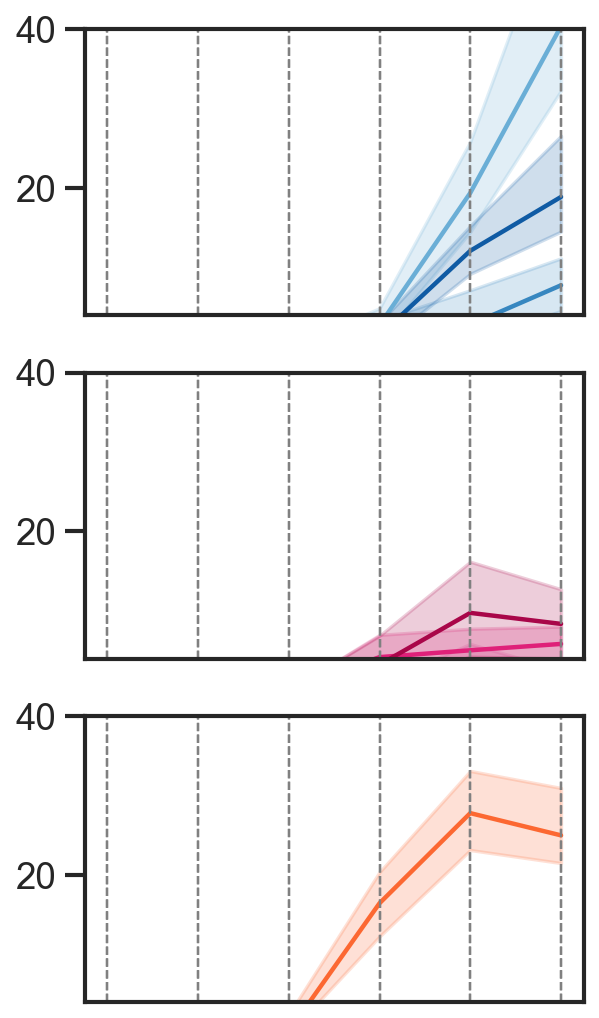

In [27]:
xval = 'time'
yval = '-log10_p'
hue = 'lin'

hue_order = ['ect1','ect2','ect3',
            'mes1','mes2','mes3',
            'end1',]
palette = ['#6AAED6', '#3787C0', '#105BA4', '#DF64AF', '#DF2179', '#A90649', '#FC6832',]


plots = [ecto,meso,endo]
order = ['ecto','meso','endo']
x=0

fig,ax = plt.subplots(3,1, figsize = (4,8))
for num, item in enumerate(plots):
    to_plot = deseq_by_day.loc[deseq_by_day['Gene'].isin(item['Gene'])]
    

    sns.lineplot(data = to_plot, linewidth = 2,
                 ax=ax[x],
                 x = xval, y = yval,hue = hue,hue_order = hue_order, palette = palette,estimator='median')

    ax[x].set_title('')
    ax[x].set_ylim([4,40])
    x=x+1

    for axes in ax:
        axes.set_xlabel('')
        axes.set_ylabel('')
        axes.set_xticks([])
        axes.legend([],frameon=False) 
        
        axes.axvline(0,linestyle = 'dashed',c = 'grey',linewidth = 1)
        axes.axvline(1,linestyle = 'dashed',c = 'grey',linewidth = 1)
        axes.axvline(2,linestyle = 'dashed',c = 'grey',linewidth = 1)
        axes.axvline(3,linestyle = 'dashed',c = 'grey',linewidth = 1)
        axes.axvline(4,linestyle = 'dashed',c = 'grey',linewidth = 1)
        axes.axvline(5,linestyle = 'dashed',c = 'grey',linewidth = 1)
        axes.axhline(-np.log10(0.05),linestyle = 'dashed',c = 'black',linewidth = 1)


plt.savefig('figures/figS6e_top_lineplot_deseq_RT_-plog10_allLin_ESCref' +str(order[num]) + '.pdf', bbox_inches='tight', format='pdf')
plt.show()